## Data Cleaning Markdown
- Collect data from Hugging Face
- Subset for variables of interest
- Plot the variables of interest in different ways
- Inspect the data
- Check for NAs
- Clean

### PHASE 1: Data Cleaning

In [32]:
# Setup
from datasets import load_dataset
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import sys
import missingno as msno

In [33]:
# Load data set for only the food products
ds = load_dataset("openfoodfacts/product-database", split="food")

In [34]:
# columns of interest
columns_of_interest = [
    "product_name",
    "brands",
    "nova_group",
    "nutriscore_score",
    "nutriscore_grade",
    "lang",
    "ingredients_original_tags",
    "code"
]

# convert to df
df = ds.select_columns(columns_of_interest).to_pandas()

In [35]:
# create data directory if it doesn't exist
if not os.path.exists("../data"):
    os.makedirs("../data")
df.to_parquet('../data/raw_data.parquet') # keeps complex data types

In [36]:
# load raw data from parquet to keep complex data types  - run from here instead of above if you have already saved the raw data
df = pd.read_parquet('../data/raw_data.parquet')

In [37]:
# Inspect first few rows of the dataset
df.head()

,product_name,brands,nova_group,nutriscore_score,nutriscore_grade,lang,ingredients_original_tags,code
0,"[{'lang': 'main', 'text': 'Véritable pâte à ta...",Bovetti,NaN,25.0,e,fr,None,0000101209159
1,"[{'lang': 'main', 'text': 'Chamomile Herbal Te...",Lagg's,1.0,NaN,unknown,en,[en:camomile-flower],0000105000011
2,"[{'lang': 'main', 'text': 'Lagg's, herbal tea,...",Lagg's,1.0,NaN,unknown,en,[en:peppermint],0000105000042
3,"[{'lang': 'main', 'text': 'Linden Flowers Tea'...",Lagg's,NaN,NaN,unknown,en,[en:linden-flowers],0000105000059
4,"[{'lang': 'main', 'text': 'Herbal Tea, Hibiscu...",Lagg's,NaN,NaN,unknown,en,[en:roselle-flower],0000105000073


In [38]:
# See rows and columns
df.shape

(4409193, 8)

In [39]:
# filter for only rows where lang is 'en'
df = df[df["lang"] == "en"]

df.shape

(1832850, 8)

In [40]:
print(type(df['product_name'].iloc[1]))

<class 'numpy.ndarray'>


In [41]:
# Extract product name from product name dictionary column
df['product_name_clean'] = df['product_name'].apply(
    lambda x: x[0]['text'] if isinstance(x, np.ndarray) and len(x) > 0 else None
)
df["product_name_clean"].head(20)

1                                  Chamomile Herbal Tea
2                        Lagg's, herbal tea, peppermint
3                                    Linden Flowers Tea
4                                  Herbal Tea, Hibiscus
5                                  Apple & Cinnamon Tea
6                                             Green Tea
7                                Shave Grass Herbal Tea
8                  Lagg's, herbal tea, chamomile * mint
9                                  Artichoke Herbal Tea
10                          Lagg's, dieter's herbal tea
11                        Lagg's, kidneytea, herbal tea
12                                            Bronchtea
13                                 100% Pure Canola Oil
14    Canola Harvest® Original Vegetable Oil Spread Tub
15    Canola harvest, buttery spread, with flaxseed oil
16                                 Lithuanian Rye Bread
20                               Magic Stars Chocolates
21                               Magic Stars Cho

In [42]:
# concatenate brand and product name to create a unique product ID - if brand is na then just use product name
df["product_ID"] = np.where(
    df["brands"].isna(),
    df["product_name_clean"].astype(str),
    df["brands"] + "_" + df["product_name_clean"].astype(str)
)

# make sure no products duplicated by "code" (barcode) - also unique product ID
if df["code"].nunique() != len(df):
    print("Warning: code column has duplicates.")

# for code duplicates keep the instance with the most data (least missing values)
df["missing_values"] = df.isna().sum(axis=1)
df = df.sort_values("missing_values").drop_duplicates(subset="code", keep="first").drop(columns="missing_values")

# double check for duplicates after dropping
if df["code"].nunique() != len(df):
    print("Warning: code column has duplicates.")
else:
    print("No duplicates in code column.")

No duplicates in code column.


In [43]:
df.shape

(1832844, 10)

### PHASE 2: Data Inspection & Plotting

In [44]:
# count na in each column
na_count = df.isna().sum()

# get percentage of missing values in each column
na_percent = df.isna().mean()*100

# combine into a dataframe
na_df = pd.DataFrame({"na_count": na_count, "na_percent": na_percent})
print(na_df)

                           na_count  na_percent
product_name                      0    0.000000
brands                       623623   34.024882
nova_group                  1306956   71.307542
nutriscore_score            1320230   72.031771
nutriscore_grade              37305    2.035361
lang                              0    0.000000
ingredients_original_tags   1208530   65.937417
code                              0    0.000000
product_name_clean           165971    9.055381
product_ID                   165971    9.055381


OBS: We have quite a lot of data without a nova group or a numerical nutriscore score. But many more do have a nutrigrade. So we should probably use the grade instead of the score - I will continue by using the nutrigrade.

Quite a lot of the data also does not have ingredients original tags - perhaps we need to check how much we have and if we use a different column from the OG data.

#### Create filtered df where there are ingredients and nutriscores

In [45]:
# filter for rows with a nutriscore_grade and ingredients_original_tags
df_filtered = df[df["nutriscore_grade"].notna() & df["ingredients_original_tags"].notna()]

df_filtered.shape

(624303, 10)

#### Inspect df with novas for NA inspection

In [46]:
# create df where nova is present
with_nova = df_filtered[df_filtered["nova_group"].notna()].copy()

with_nova.shape

(516933, 10)

In [47]:
# see how many products fall into each nova score for the with nova df
print(with_nova["nova_group"].value_counts())

nova_group
4.0    369376
3.0     87971
1.0     51279
2.0      8307
Name: count, dtype: int64


In [48]:
# see how many products fall into each nutriscore grade for the missing nova df
print(with_nova["nutriscore_grade"].value_counts())

nutriscore_grade
e                 121842
unknown           115818
d                  94558
c                  76336
a                  57829
b                  38205
not-applicable     12345
Name: count, dtype: int64


In [49]:
# exclude all rows with nutriscore_grade == "unknown" and "not-applicable" from the df_filtered data frame
df_filtered = df_filtered[~df_filtered['nutriscore_grade'].isin(['unknown', 'not-applicable'])]

#Checking if they're gone
print(df_filtered["nutriscore_grade"].value_counts())

nutriscore_grade
e    138591
d    102409
c     85838
a     65864
b     49219
Name: count, dtype: int64


#### Inspect df without novas

In [50]:
# see how many rows of the filtered dataset have a nova group
missing_nova = df_filtered[df_filtered["nova_group"].isna()].copy()

missing_nova.shape

(53151, 10)

In [51]:
# percentage of df_filtered that doesn't have a nova
percent_missing_nova = (missing_nova.shape[0] / df_filtered.shape[0]) * 100
print(f"Percentage of df_filtered without nova_group: {percent_missing_nova:.2f}%")

Percentage of df_filtered without nova_group: 12.03%


In [52]:
# see how many products fall into each nutriscore grade for the missing nova df
print(missing_nova["nutriscore_grade"].value_counts())

nutriscore_grade
e    16749
b    11014
c     9502
a     8035
d     7851
Name: count, dtype: int64


Issues to be addressed?
- For the nutriscore grade there is some called unknown and not-applicable -> need to see what we want to do with these? Filter out? or see what the use cases are?
    - not-applicable can be caused by various reasons, mainly:
        
        Alcoholic Beverages: Typically excluded from Nutri-Score calculation.
        
        Single-Ingredient Products: Foods like coffee, tea, herbal infusions, salt, vinegar, and yeast do not receive a grade because they are generally used in small quantities and contain negligible nutrients per serving. 
        
        Unprocessed Products: Raw products like fresh meat, fruit, or vegetables that are sold without additional ingredients often lack a label.
        
        Voluntary Participation: While adopted in several EU countries, Nutri-Score is voluntary, not mandatory. Companies may choose not to use it, leaving products unlabeled.
        
        Specialized Foods: Foods intended for particular nutritional uses (e.g., infant formula) are often exempt.
        
        Missing Information: Products with incomplete nutritional data in the database cannot be graded.

    MEANING: We should delete these, as they both may represent ultra-processed foods, very raw products, missing data AND products where it's simply not applicable. 
- There are varying amount in each nova group (when we split the data again it should be equal between all groups in each df? Amount of data could be seen as a weight?)
    - This will automatically be sorted later on within the stratified data splits. It's okay for now:)

In [53]:
df_filtered = df[df["nutriscore_grade"].notna() & df["ingredients_original_tags"].notna()]

In [54]:
# create output folder
if not os.path.exists("../output"):
    os.makedirs("../output")

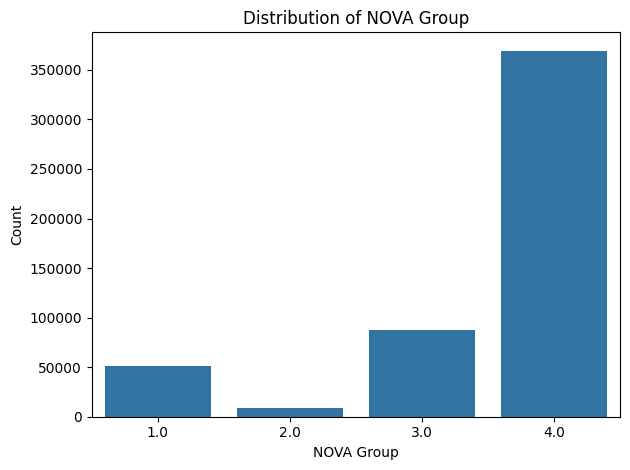

In [55]:
# Plotting the distribution of nova_group 
sns.countplot(data=df_filtered, x='nova_group', order=sorted(df_filtered['nova_group'].dropna().unique()))
plt.title('Distribution of NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../output/nova_group_distribution.png', dpi=150)
plt.show()

/var/folders/8q/0xtf9l0d2wd2qw2lng8ncfvm0000gp/T/ipykernel_17533/3996490065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='nova_group', y='nutriscore_score',


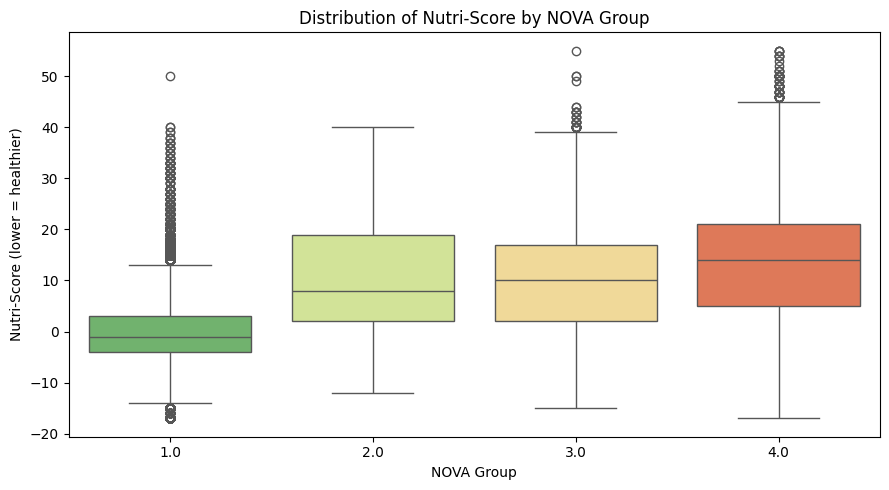

In [56]:
# plotting distribution of nutriscore_score by nova_group
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_filtered, x='nova_group', y='nutriscore_score', 
            order=sorted(df_filtered['nova_group'].dropna().unique()),
            palette='RdYlGn_r')
plt.title('Distribution of Nutri-Score by NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Nutri-Score (lower = healthier)')
plt.tight_layout()
plt.savefig('../output/nutriscore_by_nova.png', dpi=150)
plt.show()

notes on the plot above:

- RdYlGn_r is a red-yellow-green reversed palette, which maps nicely since higher nutriscore = less healthy

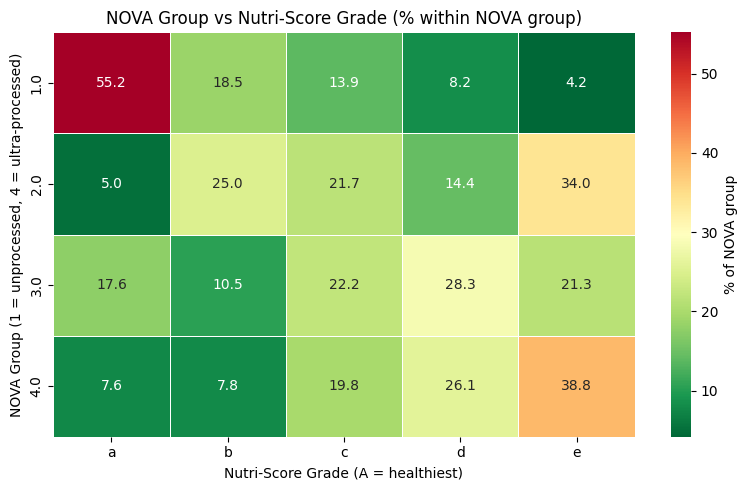

In [57]:
# Build the contingency table
heatmap_data = df_filtered.groupby(['nova_group', 'nutriscore_grade']).size().unstack(fill_value=0)

# Order the axes meaningfully
nova_order = sorted(heatmap_data.index)
nutriscore_order = ['a', 'b', 'c', 'd', 'e']
heatmap_data = heatmap_data.reindex(index=nova_order, columns=nutriscore_order)

# Normalize by row so each NOVA group sums to 100%
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '% of NOVA group'})
plt.title('NOVA Group vs Nutri-Score Grade (% within NOVA group)')
plt.xlabel('Nutri-Score Grade (A = healthiest)')
plt.ylabel('NOVA Group (1 = unprocessed, 4 = ultra-processed)')
plt.tight_layout()
plt.savefig('../output/nova_nutriscore_heatmap.png', dpi=150)
plt.show()

notes on plot above: 

- The expected pattern (processing = unhealthy):
NOVA 1 (unprocessed): 55.2% score A — most unprocessed foods are nutritionally good. This makes sense.
NOVA 4 (ultra-processed): 38.8% score E — a big chunk of ultra-processed foods score poorly. Also expected.

- The discordance — this is the interesting part:
NOVA 4 but grade A or B: 7.6% + 7.8% = 15.4% of ultra-processed foods still score well nutritionally. These are things like diet sodas, protein bars, or fortified cereals — heavily processed but engineered to hit good nutrient scores.
NOVA 2 but grade E: 31.7% — this is the biggest surprise. Lightly processed foods scoring very poorly. Think things like salted butter, cured meats, or full-fat cheese — minimally processed but high in fat/salt/sugar.

- The headline takeaway for your write-up:
Nutri-Score and NOVA group measure different things. A food can be ultra-processed yet score A, or barely processed yet score E. The two systems are complementary, not redundant — which is exactly why both matter

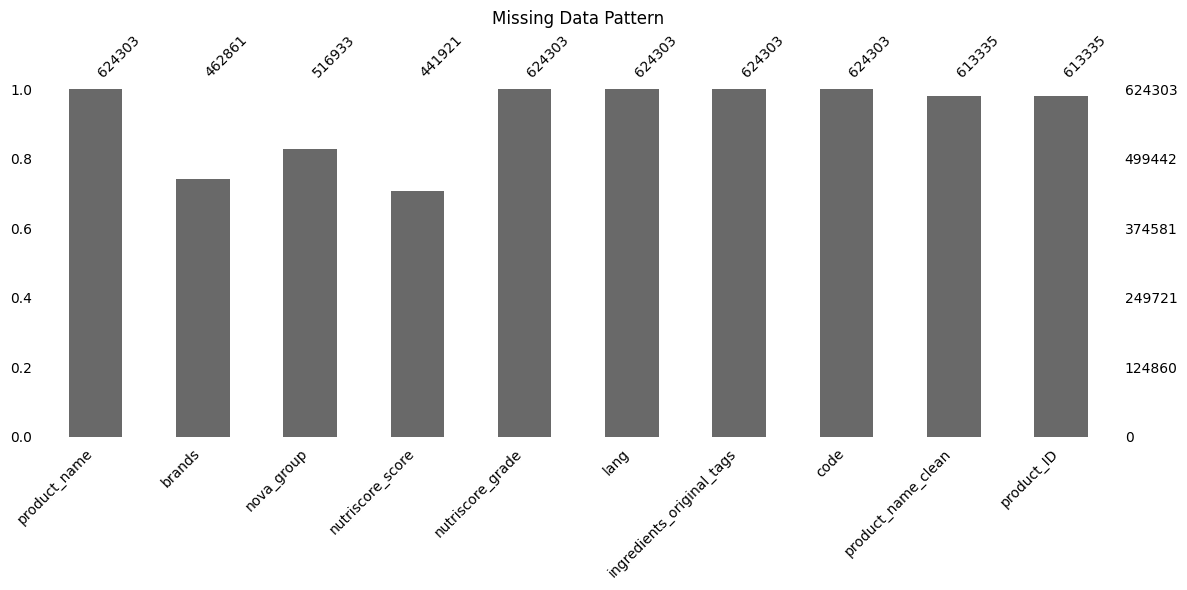

In [58]:
plt.figure()
#msno.matrix(df, figsize=(12, 6), fontsize=10, sparkline=False)
msno.bar(df_filtered, figsize=(12, 6), fontsize=10)
plt.title('Missing Data Pattern')
plt.tight_layout()
plt.savefig('../output/missing_data_pattern.png', dpi=150)
plt.show()

notes on plot above:

- Bar height = proportion of non-missing values (1.0 = fully complete, 0.0 = all missing)

- The numbers on top = actual count of non-missing rows

In [ ]:
# Save dataset to local repo but large dataset saved to huggingface
df_filtered.to_parquet("../data/cleaned_data.parquet", index=False)


# link to hugging face for reference
# ds2 = load_dataset("MattiWhen/filtered_openfood", token = token) # token in txt file